# Task2 - Image pre-processing with task3 corner detection

In this notebook, we repurpose the CNNs developed for corner detection in task3, to pre-process the images passed to the regression and classification CNNs:
- We use the chessred2k images to generate a new dataset with the same images, but warped to only include the actual chessboard region, with use of the detected corners. The images are also already apropriatey rotated so white side pieces appear at the bottom.
- The advantages we expected from this approach were to completely remove the pieces that appeared beside the board and that weren't in actual play (weren't relevant for the final piece count), which might confuse model's predictions.
- This new dataset is then used in the notebooks "task2-corners_altered_classification_unbalanced.ipynb" and "task2-corners_altered_regression_unbalanced.ipynb"
- This approach is identical to the dataset pre-processing approach with task1 traditional methods (which we followed in "task2-altered_classification_unbalanced.ipynb", and "task2-altered_regression_unbalanced.ipynb"). However the corner detection is based on CNNs, so it isn't limited by traditional methods performance. Surprisingly, this approach returned slightly worse results than the traditional warping approach.

In [ ]:
pip install -r requirements.txt

In [72]:
import os
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
import torch
import ultralytics
import random
import shutil
from tqdm import tqdm

# Check Ultralytics version
print(f"Ultralytics version: {ultralytics.__version__}")
if ultralytics.__version__ < '8.3.146':
    print("Warning: Ultralytics version is outdated. Please update with 'pip install -U ultralytics'")

# Set random seed for reproducibility
random.seed(42)

Ultralytics version: 8.3.146


# Detect Corners



Effectively detecting the chessboard corners is a vital step for successfully completing task 3. Initially, we implemented a **regression model that predicted the coordinates of 4 points** (x and y positions, so 8 values in total). Although the results were decent, it led to unsable results too often, which compromised our entire pipeline. Taking inspiration from approaches used in fields such as medical imaging, we built a **regression model that predicts 4 heatmaps**. We then extract the point of highest intensity from each of these maps, which provided us much better  results overall.

### Setup Preparation

In [73]:
import numpy as np 
import os
import torch
from torch.utils.data import Dataset, DataLoader
import json
from PIL import Image
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from torchvision import transforms
import copy
import cv2

In [74]:
def heatmaps_to_points(heatmaps):
    """
    Calculates the points of highest intensity from the heatmaps 
    """
    num_corners, _, W = heatmaps.shape
    points = []

    for i in range(num_corners):
        heatmap = heatmaps[i]
        _, idx = torch.max(heatmap.view(-1), dim=0)
        y, x = divmod(idx.item(), W)
        points.append((x, y))
    
    return points

def points_to_image_coordinates(points, origin_size, target_size):
    """
    Scales the points from the heatmap to the scale of the target image 
    """
    img_w, img_h = target_size
    scale_x = img_w / origin_size
    scale_y = img_h / origin_size
    
    image_points = [
        (x * scale_x, y * scale_y) for (x, y) in points
    ]
    
    return image_points

def make_gaussian_heatmap(size, center, sigma=2):
    """
    Creates a heatmap centered at a given point. Used to generate ground truth heatmaps for training.
    """
    x = np.arange(0, size[1], 1, np.float32)
    y = np.arange(0, size[0], 1, np.float32)
    y = y[:, np.newaxis]

    x0, y0 = center
    heatmap = np.exp(- ((x - x0) ** 2 + (y - y0) ** 2) / (2 * sigma ** 2))
    return heatmap

The **CornerDataset** class loads each image and its annotated corners, then generates a Gaussian heatmap for each corner. These heatmaps serve as the training targets, allowing the model to learn to localize each corner as a region of high intensity.

In [75]:
class CornerDataset(Dataset):
    def __init__(self, annotations, image_dir, split='train', heatmap_size=56, sigma=2):
        with open(annotations, 'r') as f:
            data = json.load(f)
            all_image_annotations = data["images"]
            corners_list = data["annotations"]["corners"]
        
        self.image_dir = image_dir
        self.corners_annotations = {
            corner['image_id']: corner['corners'] for corner in corners_list
        }
        
        self.image_annotations = []
        for item in all_image_annotations:
            img_path = os.path.join(image_dir, item["path"])
            if os.path.isfile(img_path) and (item["id"] in self.corners_annotations) and (item["id"] in data["splits"]["chessred2k"][split]["image_ids"]):
                self.image_annotations.append(item)

        print(f"Loaded {len(self.image_annotations)} images for {split} split")
        
        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor()
        ])
        
        self.heatmap_size = heatmap_size
        self.sigma = sigma

    def __len__(self):
        return len(self.image_annotations)
    
    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.image_annotations[idx]['path'])
        image = Image.open(img_path).convert("RGB")
        original_width, original_height = image.size
        image = self.transform(image)
        
        img_id = self.image_annotations[idx]['id']
        corners_dict = self.corners_annotations[img_id]
        ordered_keys = ['top_left', 'top_right', 'bottom_right', 'bottom_left']
        corners = [corners_dict[key] for key in ordered_keys]

        normalized_corners = [
            [x / original_width, y / original_height] for (x, y) in corners
        ]
        
        heatmaps = []
        for (x_norm, y_norm) in normalized_corners:
            x_hm = x_norm * self.heatmap_size
            y_hm = y_norm * self.heatmap_size
            heatmap = make_gaussian_heatmap(
                (self.heatmap_size, self.heatmap_size),
                (x_hm, y_hm),
                sigma=self.sigma
            )
            heatmaps.append(heatmap)

        heatmaps = np.stack(heatmaps)  
        heatmaps = torch.tensor(heatmaps, dtype=torch.float32)
        
        return image, img_path, heatmaps

This class defines our model, which is based on a pre-trained ResNet-34. We experimented with different architectures, but ResNet-34 provided the best balance between overall performance and training time. The final layers of the model were modified to predict heatmaps. These layers **upsample the feature maps produced by the ResNet backbone**, gradually increasing their spatial resolution. This allows the model to output a set of heatmaps (one for each corner), where each heatmap highlights the predicted location of a specific chessboard corner.

In [76]:
class ResNetHeatmap(nn.Module):
    def __init__(self, num_corners=4):
        super(ResNetHeatmap, self).__init__()
        
        resnet = models.resnet34(weights='DEFAULT')
        self.features = nn.Sequential(*list(resnet.children())[:-2])  
        
        self.head = nn.Sequential(
            nn.ConvTranspose2d(512, 256, 2, stride=2), nn.ReLU(),  
            nn.ConvTranspose2d(256, 128, 2, stride=2), nn.ReLU(),  
            nn.ConvTranspose2d(128, num_corners, 2, stride=2)       
        )

    def forward(self, x):
        x = self.features(x)
        x = self.head(x)
        return x  

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
model = ResNetHeatmap().to(device)

The dataset is divided into 3 smaller datasets, following what was studied in class:
- Training Dataset
- Eval Dataset
- Test Dataset

This division is based on the *annotations.json* file, that already makes this division for us.

In [66]:
train_dataset = CornerDataset("annotations.json", "", split='train')
val_dataset = CornerDataset("annotations.json", "", split='val')
test_dataset = CornerDataset("annotations.json", "", split='test')

batch_size = 32

train_dataloader = DataLoader(train_dataset, batch_size, shuffle=True, collate_fn=lambda x: x, num_workers=0, pin_memory=True)
val_dataloader = DataLoader(val_dataset, batch_size, collate_fn=lambda x: x, num_workers=0, pin_memory=True)
test_dataloader = DataLoader(test_dataset, batch_size, collate_fn=lambda x: x, num_workers=0, pin_memory=True)

Loaded 1442 images for train split
Loaded 330 images for val split
Loaded 306 images for test split


In [77]:
def predict_points(image, heatmap_size=56, image_size=(224, 224)):
    """
    Plots the predicted and ground truth points on the image.
    """
    with torch.no_grad():
        pred_heatmaps = model(image).cpu().squeeze(0)
    
    pred_points_hm = heatmaps_to_points(pred_heatmaps)
    pred_points_img = points_to_image_coordinates(pred_points_hm, heatmap_size, image_size)
    
    return np.array(pred_points_img)

def calculate_homography_warped(image_np, pred_points, target_size):
    
    target_corners = np.array([
        [0, 0],
        [target_size - 1, 0],
        [target_size - 1, target_size - 1],
        [0, target_size - 1],
    ], dtype=np.float32)

    H, _ = cv2.findHomography(pred_points, target_corners)
    warped_image = cv2.warpPerspective(image_np, H, (target_size, target_size))

    return H, warped_image

In [78]:
def read_image(image_path):
    image = Image.open(image_path).convert("RGB")
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor()
    ])
    return transform(image), image.size

This function is responsible to get the corners coordinates in the original image. This is what is being done:

- Read the image
- Predict the points (in *predict_points*)
- Scales the points (also in *predict_points*)

In [79]:
def get_chessboard_corners(image_path, device=None):
    """
    Get the four corners of a chessboard from an image path.
    Args:
        image_path: ID of the image to process (e.g., 'images/0/G000_IMG012')
        device: Device to run the model on ('cuda' or 'cpu' or 'mps')
    Returns:
        numpy array of corner points in order [TL, TR, BR, BL]
    """

    # Load and preprocess the image
    image_tensor, (original_width, original_height) = read_image(image_path)
    input_image = image_tensor.unsqueeze(0).to(device)

    # Predicts the points in the heatmap and scales it to 224
    board_corners = predict_points(input_image, 56, (original_width, original_height))    
    return board_corners


#### Main function to run both yolo and corner detection

Here are some of the auxiliary functions to draw, to allow for a better visualization of the results

In [80]:
def draw_chess_grid(image, target_size, color=(100, 100, 100), thickness=2):
    """Draws an 8x8 chess grid on the image."""
    square_size = target_size // 8
    for i in range(9):
        cv2.line(image, (0, i * square_size), (target_size, i * square_size), color, thickness)
        cv2.line(image, (i * square_size, 0), (i * square_size, target_size), color, thickness)
    return image

def show_chessboard_detection_results(original, warped, target_size=800):
    """
    Display the original image and warped chessboard
    """

    warped_with_grid = draw_chess_grid(warped.copy(), target_size)

    _, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    axes[0].imshow(original)
    axes[0].set_title("Original")
    axes[0].axis('off')
    
    axes[1].imshow(warped)
    axes[1].set_title("Warped Chessboard")
    axes[1].axis('off')

    axes[2].imshow(warped_with_grid)
    axes[2].set_title("Warped With Grid Chessboard")
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

In [81]:
def detect_and_warp_chessboard(image_path, device, target_size=800):    

    orig_img = cv2.imread(image_path)
    orig_img =cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)
    corner_points = get_chessboard_corners(image_path, device=device)
    
    H, warped_image = calculate_homography_warped(orig_img, corner_points, target_size)
    
    return warped_image

In [82]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"

if os.path.exists('modelo.pth'):
    print("Loading saved model...")
    model.load_state_dict(torch.load('modelo.pth', map_location=device))
else:
    print("No saved model found.")

Loading saved model...


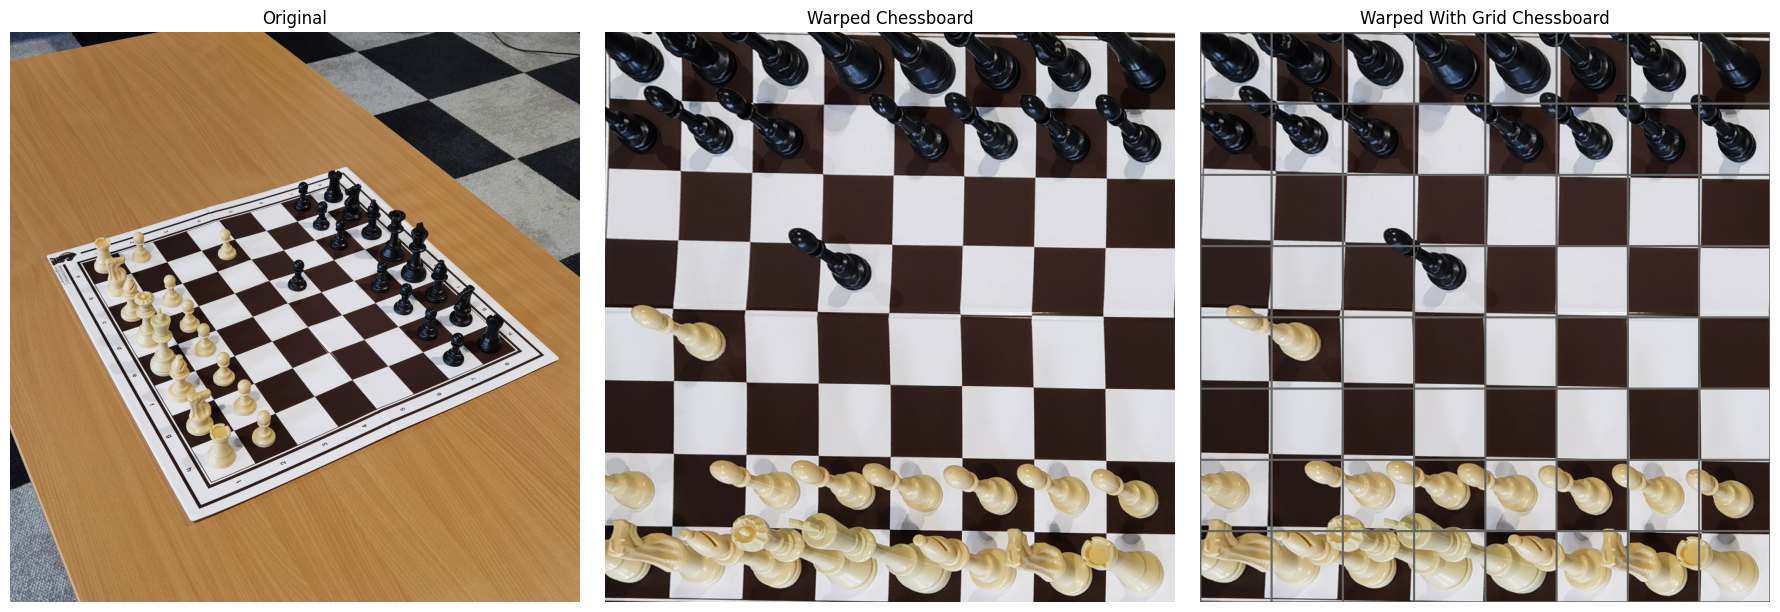

In [83]:
image_path = 'images/0/G000_IMG002.jpg' 

warped_img = detect_and_warp_chessboard(
    image_path=image_path,
    device=device,
    target_size=800
)

if warped_img is not None:
    orig_img = cv2.imread(image_path, cv2.IMREAD_COLOR_RGB)
    show_chessboard_detection_results(orig_img, warped_img)

Apply the corner detection and warping to all images in dataset, to obtain new dataset, which we will train the regression and classification approaches

In [86]:
def process_and_save_warped_images_folder(input_root, output_root, target_size=800):
    model.eval()

    # Walk through all files in input_root recursively
    for root, _, files in tqdm(os.walk(input_root), desc="Processing images"):
        image_files = [f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

        for filename in image_files:
            img_path = os.path.join(root, filename)

            # Calculate relative path from input_root for output folder structure
            rel_path = os.path.relpath(img_path, input_root)
            output_dir = os.path.join(output_root, os.path.dirname(rel_path))
            os.makedirs(output_dir, exist_ok=True)
            output_path = os.path.join(output_dir, filename)

            try:
                warped_img = detect_and_warp_chessboard(img_path, device=device, target_size=target_size)
                if warped_img is not None:
                    warped_bgr = cv2.cvtColor(warped_img, cv2.COLOR_RGB2BGR)
                    cv2.imwrite(output_path, warped_bgr)
                else:
                    print(f"Warning: Warping failed for {img_path}")
            except Exception as e:
                print(f"Error processing {img_path}: {e}")

In [87]:
input_folder = 'images'  # root input folder with subfolders like 0, 1, ...
output_folder = '/Volumes/KINGSTON/Projects/vcom_proj2/altered_images_2'

process_and_save_warped_images_folder(input_folder, output_folder, target_size=800)

Processing images: 21it [04:06, 11.73s/it]
